# Replacement Classifier 
The one supervised classification component of the pipeline: predicting `needs_replacement` from behavioral signals. This specific label was very important for learning as it brought up the issue of skewed datasets. Hence this called for importance to F1/precision/recall over any other metric.

## 1. Setup

In [1]:
import sys
sys.path.append('../V2/source')
import numpy as np
import matplotlib.pyplot as plt
import models

df = models.load_clean_data()
data = models.get_model_data(df)
print(f"{len(data)} rows, {data.battery_id.nunique()} batteries")
print(f"needs_replacement positive rate: {data.needs_replacement.mean():.4f}")

111640 rows, 140 batteries
needs_replacement positive rate: 0.0067


## 2. Problems faced with the skewed dataset

Only **0.67%** of cycles are labeled "needs replacement" -which roughly is 1 in 150. A model that always predicts "no" scores **99.3% accuracy** while being completely useless which is exactly why I mentioned that any other metric would be useless in this case. With this in mind we can understand what the model does and why ahead

## 3. Algorithm comparison

In [2]:
results, best = models.train_replacement(df)


=== Replacement classifier (GroupKFold, 5 folds) -- class balance: 0.007 positive ===
LogisticRegression F1=0.5931  Accuracy=0.9909
RandomForest       F1=0.7823  Accuracy=0.9965
GradientBoosting   F1=0.7307  Accuracy=0.9964
Best: RandomForest


Notice all three models score >99% accuracy which is expected and pretty much why accuracy is nearly useless as a comparison metric here, since even the worst model (Logistic Regression) is barely distinguishable from "always predict no" on accuracy alone. F1 tells the real story: Random Forest is meaningfully better at actually catching the rare positive class, not just avoiding false alarms.

## 4. Precision vs. recall tradeoff and why it matters in our specific use case

In [3]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, confusion_matrix, precision_recall_curve

X = data[models.MODEL_FEATURES].values
y = data['needs_replacement'].values
groups = data['battery_id'].values

gkf = GroupKFold(n_splits=5)
precs, recs = [], []
for tr, te in gkf.split(X, y, groups):
    scaler = StandardScaler(); Xtr, Xte = scaler.fit_transform(X[tr]), scaler.transform(X[te])
    m = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1)
    m.fit(Xtr, y[tr]); pred = m.predict(Xte)
    precs.append(precision_score(y[te], pred, zero_division=0))
    recs.append(recall_score(y[te], pred, zero_division=0))
print(f'Precision (avg across 5 folds): {np.mean(precs):.4f}')
print(f'Recall    (avg across 5 folds): {np.mean(recs):.4f}')

Precision (avg across 5 folds): 0.6741
Recall    (avg across 5 folds): 0.9369


**Recall (0.93) is much higher than precision (0.68)** It catches 93% of batteries that genuinely need replacement and the 68% precision means about 1 in 3 "replace" flags are false alarms which is not an issue. For a real replacement decision, missing a genuinely failing battery (low recall) is a bigger risk than an unnecessary inspection (low precision). This model agrees with real world application of similar systems and is exactly the tradeoff which is needed here

## 5. Confusion matrix + precision-recall curve (single held-out fold)

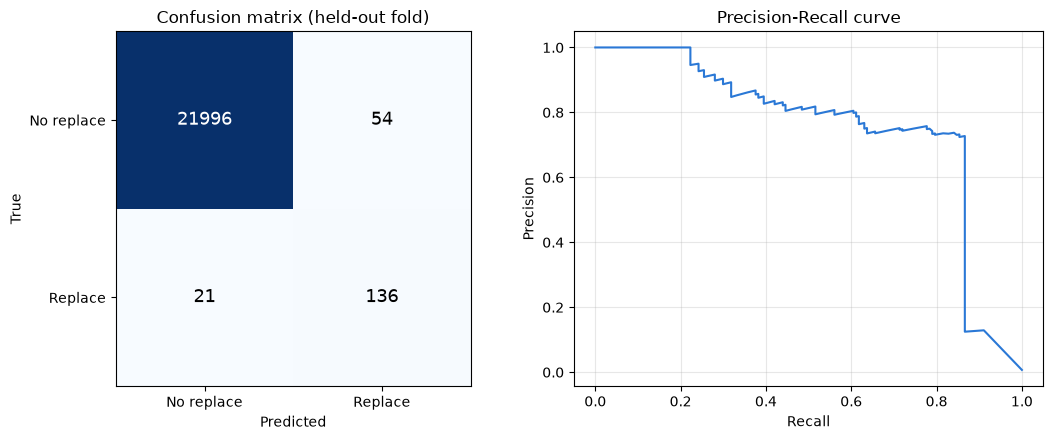

In [4]:
tr, te = next(gkf.split(X, y, groups))
scaler = StandardScaler(); Xtr, Xte = scaler.fit_transform(X[tr]), scaler.transform(X[te])
m = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1)
m.fit(Xtr, y[tr])
pred = m.predict(Xte)
proba = m.predict_proba(Xte)[:,1]

cm = confusion_matrix(y[te], pred)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,4.5))

ax1.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax1.text(j, i, str(cm[i,j]), ha='center', va='center',
                  color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=13)
ax1.set_xticks([0,1]); ax1.set_xticklabels(['No replace','Replace'])
ax1.set_yticks([0,1]); ax1.set_yticklabels(['No replace','Replace'])
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')
ax1.set_title('Confusion matrix (held-out fold)')

prec, rec, _ = precision_recall_curve(y[te], proba)
ax2.plot(rec, prec, color='#2a78d6')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall curve')
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the confusion matrix directly** (this specific fold): 136 true positives, 21 false negatives, 54 false positives, 21,996 true negatives. Recall here = 136/(136+21) = **86.6%**, precision = 136/(136+54) = **71.6%** close to but not identical to the 5-fold averages above, which is expected fold-to-fold variance with this few positive examples per fold (~157 positives spread across 5 folds is a small sample to average over).

**The PR curve** shows the real tradeoff space: this model *could* be tuned toward higher precision (fewer false alarms) by raising its decision threshold above the default 0.5, at the cost of recall (missing more real cases). Given the reasoning above missing a real failure is worse than a false alarm. The current default threshold is a defensible choice which balances precision recall quite well.

## 6. Feature importance

In [7]:
import joblib
bundle = joblib.load('../V2/models/replacement.pkl')
for f, imp in sorted(zip(bundle['features'], bundle['model'].feature_importances_), key=lambda x: -x[1]):
    print(f"  {f:18s} {imp:.4f}")

  chargetime_ratio   0.5180
  IR_ratio           0.3207
  Tmin               0.0690
  C2                 0.0317
  Tavg               0.0248
  C1                 0.0147
  Q1                 0.0109
  Tmax               0.0103


Same top-2 features as both regressors (`chargetime_ratio`, `IR_ratio` together account for ~84% of the decision). This is a consistent signal across all three supervised tasks, reinforcing that these two ratio features really are the dataset's core degradation indicators not an artifact of one particular model.

## 7. Summary

- Accuracy is nearly meaningless here (>99% for every model, including the weakest) and severe class imbalance (0.67% positive) makes F1 the metric that actually differentiates model quality.
- Random Forest wins clearly (F1=0.78) with a deliberately lopsided precision/recall (0.68/0.93). It catches the large majority of real replacement cases at the cost of some false alarms.
- Same two features (`chargetime_ratio`, `IR_ratio`) dominate this task as they did SOH and RUL which is a good sign that the features chosen are relevant to the model and task being carried out.